<a href="https://colab.research.google.com/github/minbj1226/pytorch-study/blob/main/08_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Transfer Learning이란?
- 이미 큰 데이터셋으로 학습된 모델의 가중치를 가져와, 새로운 데이터셋 문제에 맞게 재사용하는 학습 방법

### 2. pretrained model 사용 이유
- 이미 큰 데이터셋에서 유용한 특징을 학습했기 때문에, 적은 데이터로도 빠르고 좋은 성능을 얻을 수 있다.

### 3. fine-tuning과 fixed feature extractor의 차이
- fine-tuning: pretrained 모델의 여러 층 또는 전체 층의 가중치를 함께 학습하는 방식
- fixed feature extractor: pretrained 모델의 기존 가중치는 고정하고, 마지막 분류층만 새로 학습하는 방식

### 4. 마지막 fc layer를 바꾸는 이유
- pretrained 모델의 마지막 분류층은 원래 ImageNet의 1000개 클래스를 분류하도록 되어 있으므로, 현재 데이터셋의 클래스 수에 맞게 마지막 fc layer를 변경

### 5. 학습 데이터와 검증 데이터의 transform 다르게 적용하는 이유
- 학습 데이터의 경우 데이터 다양성을 늘리기 위해 augmentation을 적용하고, 검증 데이터는 일관된 기준으로 성능을 평가하기 위해 기본 전처리만 적용

### 6. requires_grad=False 사용 이유
- fixed feature extractor 방식에서는 마지막 분류층만 학습하고 기존 pretrained 층의 가중치는 업데이트하지 않기 위해 requires_grad=False를 사용

### 7. StepLR의 역할
- StepLR은 일정 epoch마다 learning rate를 줄여서 학습이 후반부에 더 안정적으로 수렴하도록 돕는 scheduler이다.

### 8. 가장 좋은 val accuracy의 모델을 저장하는 이유
- 검증 성능이 가장 좋았던 시점의 모델을 보존하여, 과적합이 진행된 마지막 epoch 대신 가장 일반화 성능이 좋은 모델을 사용하기 위해 저장

### 9. 평가 시 model.eval()과 torch.no_grad()를 함께 사용하는 이유
- 평가 시에는 Dropout과 BatchNorm이 평가 방식으로 동작하도록 model.eval()을 사용하고, gradient 계산이 필요 없으므로 torch.no_grad()를 사용

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [21]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/drive/MyDrive/Colab Notebooks/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                              shuffle= True, num_workers=4)
                  for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


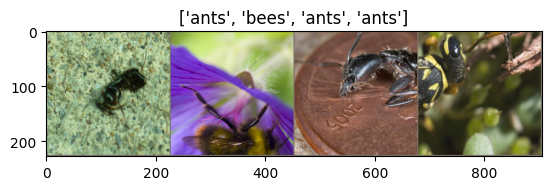

In [22]:
def imshow(inp, title=None):
  inp = inp.numpy().transpose((1, 2, 0))
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = std * inp + mean
  inp = np.clip(inp, 0, 1)
  plt.imshow(inp)
  if title is not None:
    plt.title(title)
  plt.pause(0.001)

inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [23]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
  since = time.time()

  with TemporaryDirectory() as tempdir:
    best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

    torch.save(model.state_dict(), best_model_params_path)
    best_acc = 0.0

    for epoch in range(num_epochs):
      print(f'Epoch {epoch}/{num_epochs - 1}')
      print('-' * 10)

      for phase in ['train', 'val']:
        if phase == 'train':
          model.train()
        else:
          model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
          inputs = inputs.to(device)
          labels = labels.to(device)

          optimizer.zero_grad()

          with torch.set_grad_enabled(phase == 'train'):
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            if phase == 'train':
              loss.backward()
              optimizer.step()

          running_loss += loss.item() * inputs.size(0)
          running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
          scheduler.step()

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'val' and epoch_acc > best_acc:
          best_acc = epoch_acc
          torch.save(model.state_dict(), best_model_params_path)
      print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(torch.load(best_model_params_path))
  return model

In [24]:
def visualize_model(model, num_images=6):
  was_training = model.training
  model.eval()
  images_so_far = 0
  fig = plt.figure()

  with torch.no_grad():
    for i, (inputs, labels) in enumerate(dataloaders['val']):
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)

      for j in range(inputs.size()[0]):
        images_so_far += 1
        ax = plt.subplot(num_images//2, 2, images_so_far)
        ax.axis('off')
        ax.set_title(f'predicted: {class_names[preds[j]]}')
        imshow(inputs.cpu().data[j])

        if images_so_far == num_images:
          model.training = was_training
          return
    model.training = was_training

In [25]:
#Finetuning the ConvNet
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6649 Acc: 0.6598
val Loss: 0.3457 Acc: 0.8366

Epoch 1/24
----------
train Loss: 0.4969 Acc: 0.7910
val Loss: 0.2113 Acc: 0.9412

Epoch 2/24
----------
train Loss: 0.4740 Acc: 0.8074
val Loss: 0.3430 Acc: 0.8693

Epoch 3/24
----------
train Loss: 0.6511 Acc: 0.7623
val Loss: 0.3181 Acc: 0.8758

Epoch 4/24
----------
train Loss: 0.5173 Acc: 0.7992
val Loss: 0.3909 Acc: 0.8627

Epoch 5/24
----------
train Loss: 0.5000 Acc: 0.8033
val Loss: 0.2991 Acc: 0.9020

Epoch 6/24
----------
train Loss: 0.5147 Acc: 0.8074
val Loss: 0.3920 Acc: 0.8366

Epoch 7/24
----------
train Loss: 0.4364 Acc: 0.8074
val Loss: 0.2763 Acc: 0.8889

Epoch 8/24
----------
train Loss: 0.4065 Acc: 0.8361
val Loss: 0.2566 Acc: 0.9150

Epoch 9/24
----------
train Loss: 0.2926 Acc: 0.8770
val Loss: 0.2353 Acc: 0.9216

Epoch 10/24
----------
train Loss: 0.2686 Acc: 0.8811
val Loss: 0.2340 Acc: 0.9216

Epoch 11/24
----------
train Loss: 0.3106 Acc: 0.8689
val Loss: 0.2312 Acc: 0.9216

Ep

In [ ]:
visualize_model(model_ft)

In [ ]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
  param.requires_grad = False

num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

In [ ]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [ ]:
def visualize_model_predictions(model, img_path):
  was_training = model.training
  model.eval()

  img = Image.open(img_path)
  img = data_transforms['val'](img)
  img = img.unsqueeze(0)
  img = img.to(device)

  with torch.no_grad():
    outputs = model(img)
    _, preds = torch.max(outputs, 1)

    ax = plt.subplot(2, 2, 1)
    ax.axis('off')
    ax.set_title(f'Predicted: {class_names[preds[0]]}')
    imshow(img.cpu().data[0])

    model.train(mode=was_training)

In [ ]:
visualize_model_predictions(
    model_conv,
    img_path='/content/drive/MyDrive/Colab Notebooks/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()